In [1]:
import pickle

import flax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import regina

from pachner_traversal.data_io import Dataset, Encoder
from pachner_traversal.transformer import (MinimalTrainState, Transformer,
                                           generate_samples)
from pachner_traversal.utils import data_path, set_style

set_style()

In [2]:
load_path_pairs = (
    data_path
    / "results"
    / "sgd_models_dehydration"
    / "spheres_256emb_6block_8head_13tet"
    / "20251209_1036"
)

load_path_pairds_nd = (
    data_path
    / "results"
    / "sgd_models_dehydration"
    / "spheres_256emb_6block_8head_13tet"
    / "20251210_0845"
)

load_path_indep = (
    data_path
    / "results"
    / "sgd_models_dehydration"
    / "spheres_256emb_6block_8head_13tet"
    / "20251210_2255"
)

load_path_encoded = (
    data_path
    / "results"
    / "sgd_models_dehydration"
    / "spheres_256emb_6block_8head_13tet"
    / "20251213_0904"
)

assert load_path_indep.exists()
assert load_path_encoded.exists()
assert load_path_pairs.exists()
assert load_path_pairds_nd.exists()

In [3]:
test_losses_indep = pd.read_csv(load_path_indep / "test_losses.csv", index_col=0)[
    "0"
] * (12 + 12 + 4 + 1)
test_losses_encoded = pd.read_csv(load_path_encoded / "test_losses.csv", index_col=0)[
    "0"
] * (12 + 12 + 4 + 1)
test_losses_pairs = pd.read_csv(load_path_pairs / "test_losses.csv", index_col=0)[
    "0"
] * (12 + 1 + 2)
test_losses_pairs_nd = pd.read_csv(
    load_path_pairds_nd / "test_losses.csv", index_col=0
)["0"] * (12 + 1 + 2)

In [4]:
def fit_entropy(data, c_range):
    scores = {}
    for c in c_range:
        score = np.corrcoef(np.log(data - c), np.log(data.index + 1))[0, 1]
        scores[c] = score**2

    return scores

In [14]:
scores_indep = fit_entropy(test_losses_indep, np.linspace(29, 30, 100))
scores_encoded = fit_entropy(test_losses_encoded, np.linspace(29, 30, 100))
scores_pairs = fit_entropy(test_losses_pairs, np.linspace(29, 30, 100))

ent_indep = pd.Series(scores_indep).idxmax()
ent_encoded = pd.Series(scores_encoded).idxmax()
ent_pairs = pd.Series(scores_pairs).idxmax()

In [15]:
ent_indep

np.float64(29.92929292929293)

In [16]:
ent_encoded

np.float64(29.95959595959596)

In [13]:
ent_pairs

np.float64(30.93939393939394)

<Axes: >

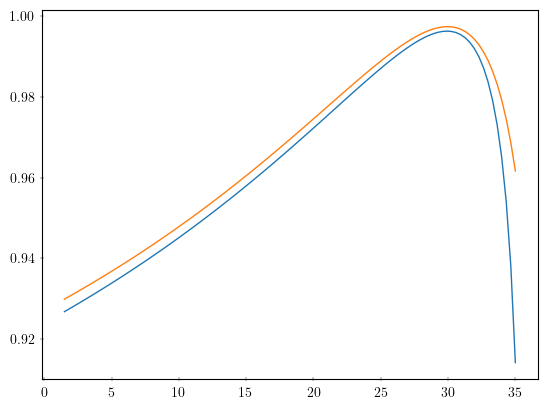

In [6]:
pd.Series(scores_indep).plot()
pd.Series(scores_encoded).plot()

[]

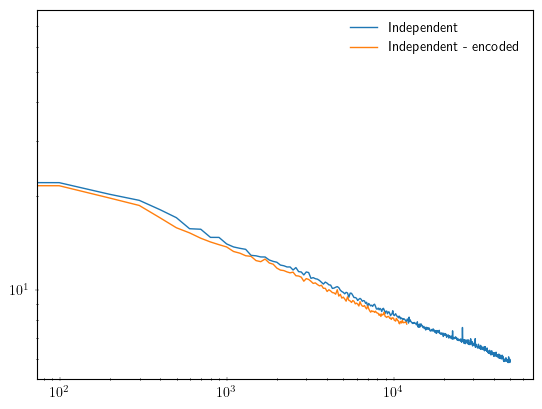

In [10]:
(test_losses_indep - ent_encoded).plot(label="Independent")
(test_losses_encoded - ent_encoded).plot(label="Independent - encoded")
# (test_losses_pairs * (12+1+2)).plot(label='Pairs')
# (test_losses_pairs_nd * (12+1+2)).plot(label='Pairs ND')

plt.legend()
# plt.ylim([None, 60])
plt.loglog()